In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import init_printing
import sympy as sym
from scipy.integrate import solve_ivp
init_printing()

# Problem 1

1. a)

First, by inspection we can easily see that (a),(b),and (c) are strongly connected. (a) and (c) both have paths that go around through all nodes, and in (b) any node can get to any other node by going through node 1. (d) is not strongly connected because there is no path out of node 6.

 The adjacency matricies for each graph are:

In [3]:
Aa = np.array([[0,1,1,0,0,1,1],[1,0,1,1,0,0,1],[1,1,0,1,1,0,0],[0,1,1,0,1,1,0],[0,0,1,1,0,1,1],[1,0,0,1,1,0,1],[1,1,0,0,1,1,0]])
Ab = np.array([[0,1,1,1,1,1,1],[1,0,0,0,0,0,0],[1,0,0,0,0,0,0],[1,0,0,0,0,0,0],[1,0,0,0,0,0,0],[1,0,0,0,0,0,0],[1,0,0,0,0,0,0]])
Ac = np.array([[0,1,1,0,1,0,0],[0,0,1,0,0,0,0],[0,0,0,1,0,0,0],[0,0,0,0,1,0,0],[0,0,0,0,0,1,0],[0,0,0,0,0,0,1],[1,0,0,0,0,0,0]]).T
Ad = np.array([[0,1,0,0,0,0,0],[0,0,1,0,0,0,0],[1,0,0,0,0,0,0],[0,0,0,0,1,0,0],[0,0,0,1,0,0,0],[1,0,0,1,0,0,1],[1,0,0,1,0,0,0]])

print("Adjacency matrix for (a):")
sym.Matrix(Aa)

Adjacency matrix for (a):


⎡0  1  1  0  0  1  1⎤
⎢                   ⎥
⎢1  0  1  1  0  0  1⎥
⎢                   ⎥
⎢1  1  0  1  1  0  0⎥
⎢                   ⎥
⎢0  1  1  0  1  1  0⎥
⎢                   ⎥
⎢0  0  1  1  0  1  1⎥
⎢                   ⎥
⎢1  0  0  1  1  0  1⎥
⎢                   ⎥
⎣1  1  0  0  1  1  0⎦

In [4]:
print("Adjacency matrix for (b):")
sym.Matrix(Ab)

Adjacency matrix for (b):


⎡0  1  1  1  1  1  1⎤
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎣1  0  0  0  0  0  0⎦

In [5]:
print("Adjacency matrix for (c):")
sym.Matrix(Ac)

Adjacency matrix for (c):


⎡0  0  0  0  0  0  1⎤
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢1  1  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  1  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  1  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  1  0  0⎥
⎢                   ⎥
⎣0  0  0  0  0  1  0⎦

In [6]:
print("Adjacency matrix for (d):")
sym.Matrix(Ad)

Adjacency matrix for (d):


⎡0  1  0  0  0  0  0⎤
⎢                   ⎥
⎢0  0  1  0  0  0  0⎥
⎢                   ⎥
⎢1  0  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  1  0  0⎥
⎢                   ⎥
⎢0  0  0  1  0  0  0⎥
⎢                   ⎥
⎢1  0  0  1  0  0  1⎥
⎢                   ⎥
⎣1  0  0  1  0  0  0⎦

It is easy to compute $\Delta$ and $L$ now that we have all of the adjacency matricies:

In [7]:
def get_D_L(A):
    # there's no real reason to code for this part of the problem but maybe this will be handy to have on hand in the future
    n = A.shape[1]
    D = np.diag([sum(A[i,:]) for i in range(n)]) # i LOVE list comprehensions
    L = D-A
    return D,L

Da,La = get_D_L(Aa)
Db,Lb = get_D_L(Ab)
Dc,Lc = get_D_L(Ac)
Dd,Ld = get_D_L(Ad)

print("Degree matrix for (a):")
sym.Matrix(Da)

Degree matrix for (a):


⎡4  0  0  0  0  0  0⎤
⎢                   ⎥
⎢0  4  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  4  0  0  0  0⎥
⎢                   ⎥
⎢0  0  0  4  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  4  0  0⎥
⎢                   ⎥
⎢0  0  0  0  0  4  0⎥
⎢                   ⎥
⎣0  0  0  0  0  0  4⎦

In [8]:
print("Degree matrix for (b):")
sym.Matrix(Db)

Degree matrix for (b):


⎡6  0  0  0  0  0  0⎤
⎢                   ⎥
⎢0  1  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  1  0  0  0  0⎥
⎢                   ⎥
⎢0  0  0  1  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  1  0  0⎥
⎢                   ⎥
⎢0  0  0  0  0  1  0⎥
⎢                   ⎥
⎣0  0  0  0  0  0  1⎦

In [9]:
print("Degree matrix for (c):")
sym.Matrix(Dc)

Degree matrix for (c):


⎡1  0  0  0  0  0  0⎤
⎢                   ⎥
⎢0  1  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  2  0  0  0  0⎥
⎢                   ⎥
⎢0  0  0  1  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  2  0  0⎥
⎢                   ⎥
⎢0  0  0  0  0  1  0⎥
⎢                   ⎥
⎣0  0  0  0  0  0  1⎦

In [10]:
print("Degree matrix for (d):")
sym.Matrix(Dd)

Degree matrix for (d):


⎡1  0  0  0  0  0  0⎤
⎢                   ⎥
⎢0  1  0  0  0  0  0⎥
⎢                   ⎥
⎢0  0  1  0  0  0  0⎥
⎢                   ⎥
⎢0  0  0  1  0  0  0⎥
⎢                   ⎥
⎢0  0  0  0  1  0  0⎥
⎢                   ⎥
⎢0  0  0  0  0  3  0⎥
⎢                   ⎥
⎣0  0  0  0  0  0  2⎦

In [11]:
print("Laplacian matrix for (a):")
sym.Matrix(La)

Laplacian matrix for (a):


⎡4   -1  -1  0   0   -1  -1⎤
⎢                          ⎥
⎢-1  4   -1  -1  0   0   -1⎥
⎢                          ⎥
⎢-1  -1  4   -1  -1  0   0 ⎥
⎢                          ⎥
⎢0   -1  -1  4   -1  -1  0 ⎥
⎢                          ⎥
⎢0   0   -1  -1  4   -1  -1⎥
⎢                          ⎥
⎢-1  0   0   -1  -1  4   -1⎥
⎢                          ⎥
⎣-1  -1  0   0   -1  -1  4 ⎦

In [12]:
print("Laplacian matrix for (b):")
sym.Matrix(Lb)

Laplacian matrix for (b):


⎡6   -1  -1  -1  -1  -1  -1⎤
⎢                          ⎥
⎢-1  1   0   0   0   0   0 ⎥
⎢                          ⎥
⎢-1  0   1   0   0   0   0 ⎥
⎢                          ⎥
⎢-1  0   0   1   0   0   0 ⎥
⎢                          ⎥
⎢-1  0   0   0   1   0   0 ⎥
⎢                          ⎥
⎢-1  0   0   0   0   1   0 ⎥
⎢                          ⎥
⎣-1  0   0   0   0   0   1 ⎦

In [13]:
print("Laplacian matrix for (c):")
sym.Matrix(Lc)

Laplacian matrix for (c):


⎡1   0   0   0   0   0   -1⎤
⎢                          ⎥
⎢-1  1   0   0   0   0   0 ⎥
⎢                          ⎥
⎢-1  -1  2   0   0   0   0 ⎥
⎢                          ⎥
⎢0   0   -1  1   0   0   0 ⎥
⎢                          ⎥
⎢-1  0   0   -1  2   0   0 ⎥
⎢                          ⎥
⎢0   0   0   0   -1  1   0 ⎥
⎢                          ⎥
⎣0   0   0   0   0   -1  1 ⎦

In [14]:
print("Laplacian matrix for (d):")
sym.Matrix(Ld)

Laplacian matrix for (d):


⎡1   -1  0   0   0   0  0 ⎤
⎢                         ⎥
⎢0   1   -1  0   0   0  0 ⎥
⎢                         ⎥
⎢-1  0   1   0   0   0  0 ⎥
⎢                         ⎥
⎢0   0   0   1   -1  0  0 ⎥
⎢                         ⎥
⎢0   0   0   -1  1   0  0 ⎥
⎢                         ⎥
⎢-1  0   0   -1  0   3  -1⎥
⎢                         ⎥
⎣-1  0   0   -1  0   0  2 ⎦

b) The eigenvalues can be computed numerically using numpy.

In [35]:
def eval_calculator(A):
    n = A.shape[1]
    evals = np.linalg.eigvals(A)
    evals[abs(evals)<0.0000001]=0.0 # make things close to zero appear as zero
    return evals

print("Eigenvalues of L for (a):")
sym.Matrix(eval_calculator(La))

Eigenvalues of L for (a):


⎡      0.0       ⎤
⎢                ⎥
⎢6.24697960371747⎥
⎢                ⎥
⎢3.19806226419516⎥
⎢                ⎥
⎢4.55495813208737⎥
⎢                ⎥
⎢6.24697960371747⎥
⎢                ⎥
⎢4.55495813208737⎥
⎢                ⎥
⎣3.19806226419516⎦

In [16]:
print("Eigenvalues of L for (b):")
sym.Matrix(eval_calculator(Lb))

Eigenvalues of L for (b):


⎡7.0⎤
⎢   ⎥
⎢0.0⎥
⎢   ⎥
⎢1.0⎥
⎢   ⎥
⎢1.0⎥
⎢   ⎥
⎢1.0⎥
⎢   ⎥
⎢1.0⎥
⎢   ⎥
⎣1.0⎦

In [17]:
print("Eigenvalues of L for (c):")
sym.Matrix(eval_calculator(Lc))

Eigenvalues of L for (c):


⎡                   0                   ⎤
⎢                                       ⎥
⎢0.767214384061616 + 0.792551992515449⋅ⅈ⎥
⎢                                       ⎥
⎢0.767214384061616 - 0.792551992515449⋅ⅈ⎥
⎢                                       ⎥
⎢           2.46557123187677            ⎥
⎢                                       ⎥
⎢       1.5 + 0.866025403784439⋅ⅈ       ⎥
⎢                                       ⎥
⎢       1.5 - 0.866025403784439⋅ⅈ       ⎥
⎢                                       ⎥
⎣                  2.0                  ⎦

In [18]:
print("Eigenvalues of L for (d):")
sym.Matrix(eval_calculator(Ld))

Eigenvalues of L for (d):


⎡           3.0           ⎤
⎢                         ⎥
⎢           2.0           ⎥
⎢                         ⎥
⎢            0            ⎥
⎢                         ⎥
⎢1.5 + 0.866025403784439⋅ⅈ⎥
⎢                         ⎥
⎢1.5 - 0.866025403784439⋅ⅈ⎥
⎢                         ⎥
⎢           2.0           ⎥
⎢                         ⎥
⎣            0            ⎦

c) I've created a function to solve this problem for (a),(b),(c). I also compute $\mathbf{w}^\top L = 0$ and $\mathbf{w}^\top \mathbf{1}=1$ to verify the solution is correct.

In [19]:
def find_w(L):
    vals, vecs = np.linalg.eig(L.T)
    w = vecs.T[np.argmin(np.abs(vals))] # select eigvec with associated zero eigenvalue
    return w/(w.T@np.ones(7)) # normalize

wa = find_w(La)
print("w for (a): ",wa)
print("w^T1=",wa@np.ones(7))
z = La.T@wa
z[np.abs(z)<0.000001]=0
print("w^TL=",z)

w for (a):  [0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.14285714
 0.14285714]
w^T1= 1.0
w^TL= [0. 0. 0. 0. 0. 0. 0.]


In [20]:
wb = find_w(Lb)
print("w for (b): ",wb)
print("w^T1=",wb@np.ones(7))
z = Lb.T@wb
z[np.abs(z)<0.000001]=0
print("w^TL=",z)

w for (b):  [0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.14285714
 0.14285714]
w^T1= 1.0000000000000002
w^TL= [0. 0. 0. 0. 0. 0. 0.]


In [21]:
wc = find_w(Lc)
print("w for (c): ",wc)
print("w^T1=",wc@np.ones(7))
z = Lc.T@wc
z[np.abs(z)<0.000001]=0
print("w^TL=",z)

w for (c):  [0.22222222+0.j 0.05555556+0.j 0.05555556+0.j 0.11111111+0.j
 0.11111111+0.j 0.22222222+0.j 0.22222222+0.j]
w^T1= (1+0j)
w^TL= [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


For (d) we have to be a little more careful. There are 2 zero eigenvalues, so we can find two such w vectors.

In [22]:
vals,vecs = np.linalg.eig(Ld.T)
print(vals) # print this to see the right index for zero eigenvalues

[-9.48016287e-17+0.j         1.50000000e+00+0.8660254j
  1.50000000e+00-0.8660254j  2.00000000e+00+0.j
  0.00000000e+00+0.j         2.00000000e+00+0.j
  3.00000000e+00+0.j       ]


In [23]:
wd1 = vecs.T[0]
wd2 = vecs.T[4]
wd1 = wd1/(wd1@np.ones(7))
wd2 = wd2/(wd2@np.ones(7))

print(wd1@np.ones(7),wd2@np.ones(7))

z1 = Ld.T@wd1
z1[np.abs(z1)<0.000001]=0
z2 = Ld.T@wd2
z2[np.abs(z1)<0.000001]=0
print(z1)
print(z2)

(1+0j) (1+0j)
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


d)

(a) and (b) are undirected (every edge points both directions with the same weight), so they are automatically weight-balanced since their adjacency matrix is symmetric. idk how to do the rest of it

2. 

a) The graphs (a),(b),and(c) will reach consensus, because they are strongly connected. (d) is not strongly connected so it may not reach consensus. The first two graphs are weight balanced, so they also will converge to an average of the initial condition.

b)

In [33]:
x0 = np.array([1,2,3,4,5,6,7])
avg = 1/7 * sum(x0)
print("average of initial condition=", avg)
print("-----------")

consensus_a = wa.T@x0
print("consensus alpha for (a)=",consensus_a)
print("-----------")
consensus_b = wb.T@x0
print("consensus alpha for (b)=",consensus_b)
print("-----------")
consensus_c = wc.T@x0
print("consensus alpha for (c)=",consensus_c)

average of initial condition= 4.0
-----------
consensus alpha for (a)= 4.0
-----------
consensus alpha for (b)= 4.000000000000001
-----------
consensus alpha for (c)= (4.388888888888888+0j)


c) The slowest decay rate is determined by $\lambda_2$, the nonzero eigenvalue of $L$ with the smallest real part.These can be extracted from the calculation we've done above:

In [48]:
E=eval_calculator(La)
lam_2 = np.real(E[E!=0]).min()
print("Re(lambda_2) for (a)=",lam_2)

E=eval_calculator(Lb)
lam_2 = np.real(E[E!=0]).min()
print("Re(lambda_2) for (b)=",lam_2)

E=eval_calculator(Lc)
lam_2 = np.real(E[E!=0]).min()
print("Re(lambda_2) for (c)=",lam_2)

Re(lambda_2) for (a)= 3.1980622641951615
Re(lambda_2) for (b)= 0.9999999999999998
Re(lambda_2) for (c)= 0.7672143840616164


Since the slowest decay looks like $e^{-\lambda_2 t}$, larger values for $\lambda_2$ decay quicker. Therefore (a) should reach consensus fastest, followed by (b) and then (c).

3.

Text(0.5, 0, 't')

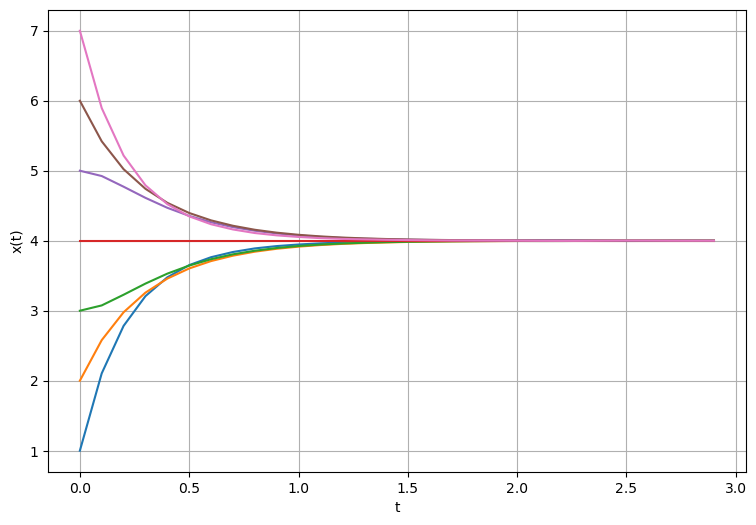

In [ ]:
def f1(t,x):
    return -La@x

tspan = (0,3)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f1,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t")

Text(0.5, 0, 't')

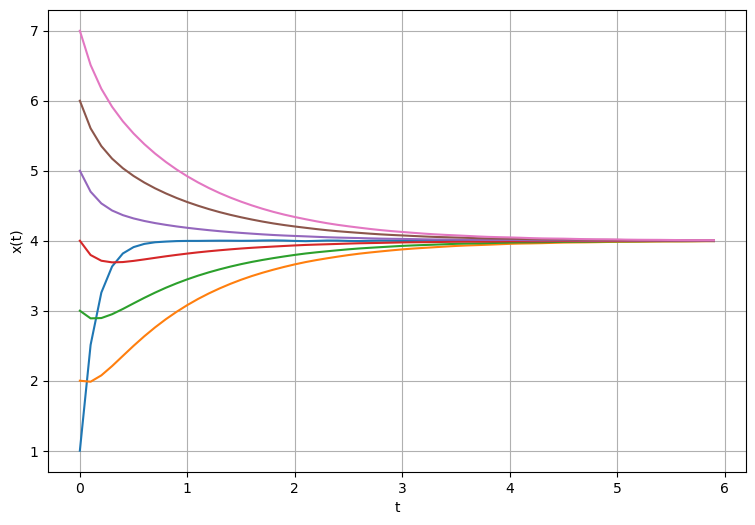

In [70]:
def f1(t,x):
    return -Lb@x

tspan = (0,6)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f1,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t")

Text(0.5, 0, 't')

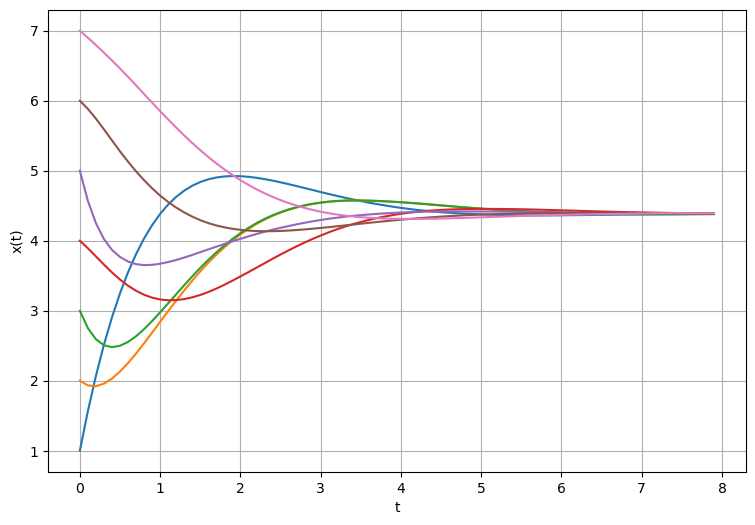

In [71]:
def f1(t,x):
    return -Lc@x

tspan = (0,8)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f1,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t")

Text(0.5, 0, 't')

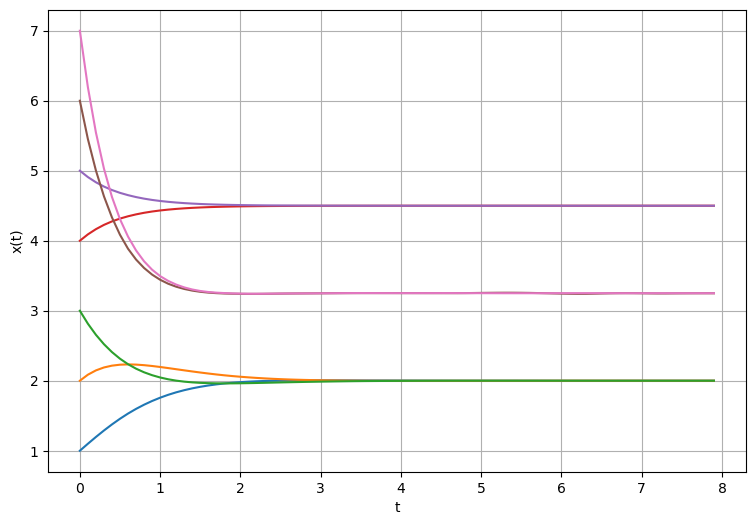

In [120]:
def f1(t,x):
    return -Ld@x

tspan = (0,8)

t_eval = np.arange(tspan[0],tspan[1],0.1)
sol = solve_ivp(f1,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(sol.t,sol.y[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t")

b) come back to this later

c) Here are the simulations:

Text(0.5, 1.0, 'discrete time consensus of (a), $\\Delta t = 1/5$')

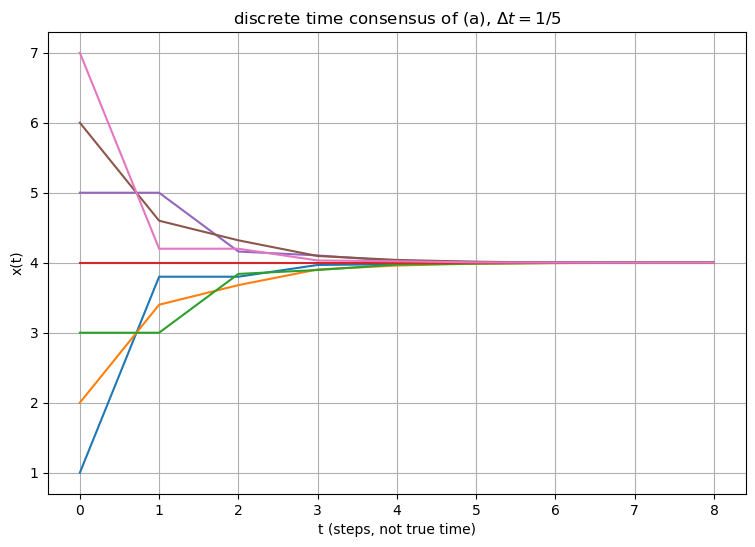

In [165]:
def simulate_discrete(L,x0,dt,tf):
    W = np.identity(7)-dt*L
    lst = [x0]
    t =0
    x = x0
    while t <=tf:
        x = W@x
        #print(x)
        lst.append(x)
        #print(t)
        t += dt
    return np.asarray(lst)


lst = simulate_discrete(La,x0,1/5, 1.5)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t (steps, not true time)")
plt.title(r"discrete time consensus of (a), $\Delta t = 1/5$")


Text(0.5, 1.0, 'discrete time consensus of (b), $\\Delta t = 1/7$')

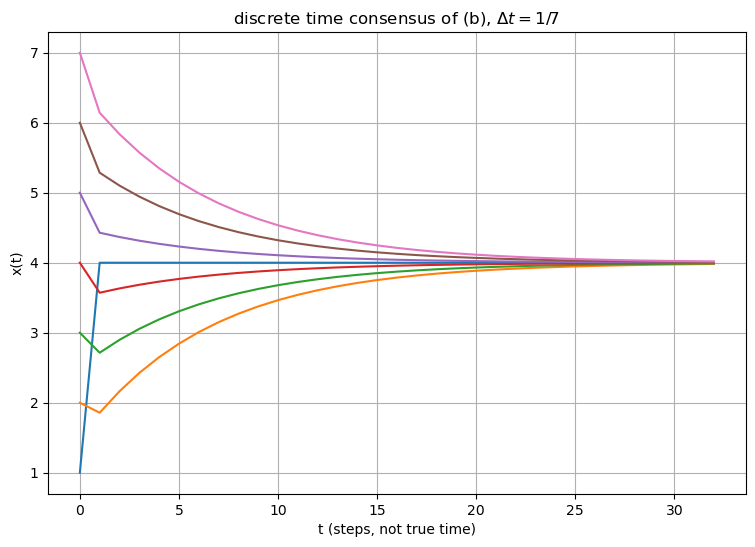

In [123]:
lst = simulate_discrete(Lb,x0,1/7, 4.5)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])
plt.grid()
plt.ylabel("x(t)")
plt.xlabel("t (steps, not true time)")
plt.title(r"discrete time consensus of (b), $\Delta t = 1/7$")

Text(0.5, 0, 't (steps, not true time)')

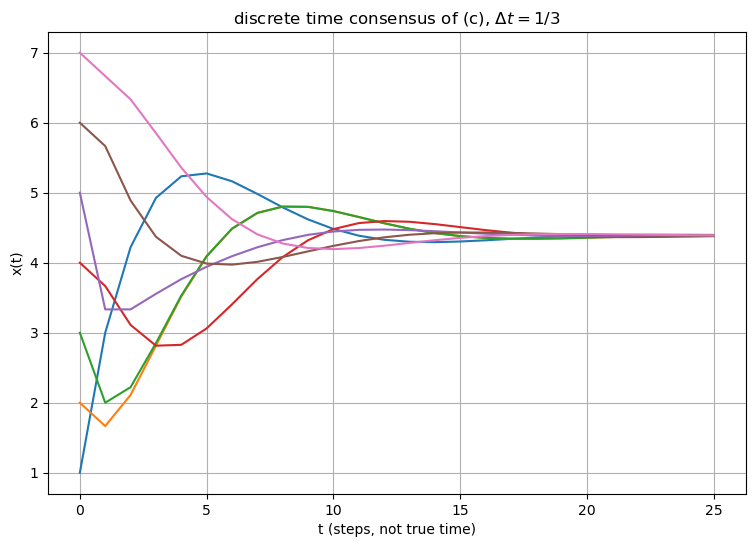

In [129]:
lst = simulate_discrete(Lc,x0,1/3, 8)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])
plt.grid()
plt.ylabel("x(t)")
plt.title(r"discrete time consensus of (c), $\Delta t = 1/3$")
plt.xlabel("t (steps, not true time)")

Text(0.5, 0, 't (steps, not true time)')

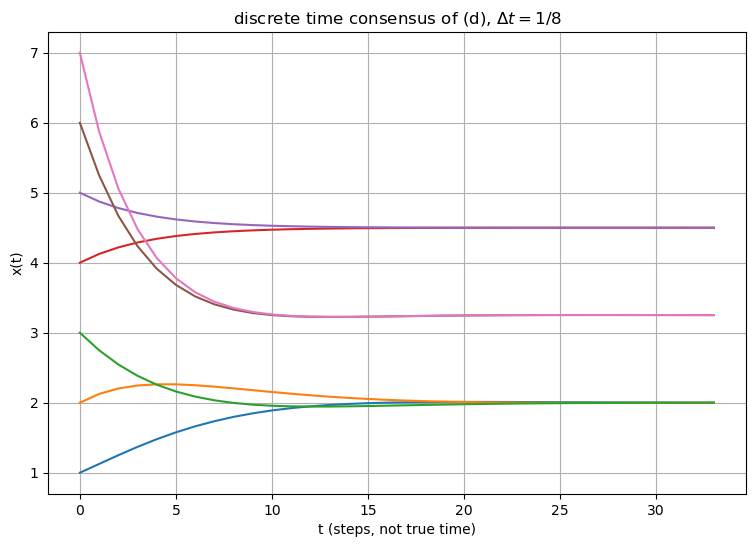

In [122]:
lst = simulate_discrete(Ld,x0,1/8, 4)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])
plt.grid()
plt.ylabel("x(t)")
plt.title(r"discrete time consensus of (d), $\Delta t = 1/8$")
plt.xlabel("t (steps, not true time)")

To choose the time steps, I looked at the maximal in degree, $d_{max}$, then set the time step to be $\frac{1}{d_{max}+1}$. We know from class that this is an adequatley small time step to ensure the euler discretization is stable. Of course I also could have chosen these using the $\frac{2}{\lambda_{max}} bound, but since in this case it is so easy to see the maximum degree I just went with that.

We could choose a smaller time step, say 1/8 for (c):

Text(0.5, 0, 't (steps, not true time)')

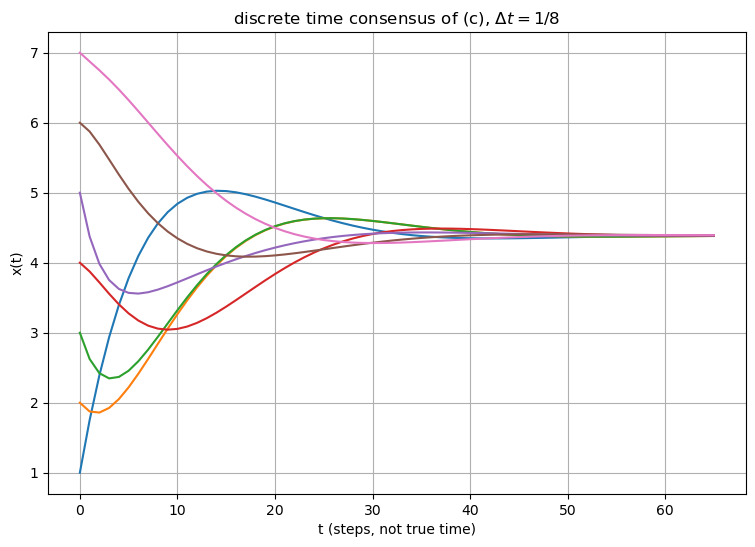

In [158]:
lst = simulate_discrete(Lc,x0,1/8, 8)

plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])
plt.grid()
plt.ylabel("x(t)")
plt.title(r"discrete time consensus of (c), $\Delta t = 1/8$")
plt.xlabel("t (steps, not true time)")

By inspecting the graphs, it is clear that choosing a smaller time step requires more iterations to converge. With $\Delta t = 1/8$, consensus is reached in around 60 iterations, while it only takes around 25 with $\Delta t = 1/3$.

4) This is mostly a matter of coding. Since both (a) and (b) are strongly connected, we still expect convergence to the average. My switching rule will be to switch uniformly at random with probability 1/3.

Text(0.5, 0, 't (steps, not true time)')

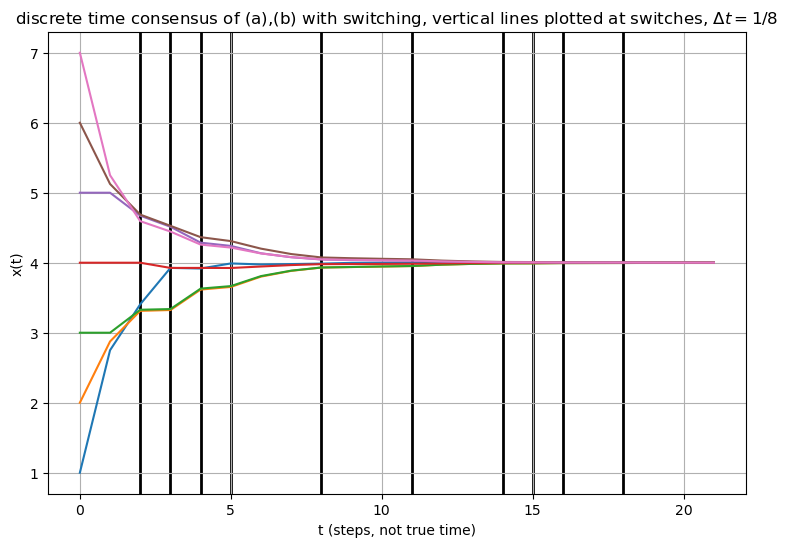

In [169]:
p = 1/4

def simulate_discrete_switching(L1,L2,x0,dt,tf,mode=0,p=1/4):
    # I'm sure there is a more optimal way of doing this... but this works so its fine
    lst = [x0]
    x = x0
    t=0
    W1 = np.identity(7)-dt*L1
    W2 = np.identity(7)-dt*L2
    modes = [mode]

    while t<=tf:
        if np.random.rand() <= p:
            mode = (mode+1)%2
        
        if mode == 0:
            x = W1@x
        elif mode == 1:
            x = W2@x
        lst.append(x)
        t+=dt
        modes.append(mode)
    return np.asarray(lst),modes

lst,modes = simulate_discrete_switching(La,Lb,x0,1/8,2.5,mode=0,p=1/3)


plt.figure(figsize=(9,6))
for i in range(7):
    plt.plot(lst.T[i])

for i in range(len(modes)-1):
    if modes[i] != modes[i+1]:
        plt.axvline(i,zorder = 0,color = "black",lw = 2)

plt.grid()
plt.ylabel("x(t)")
plt.title(r"discrete time consensus of (a),(b) with switching, vertical lines plotted at switches, $\Delta t = 1/8$")
#plt.legend()
plt.xlabel("t (steps, not true time)")

As expected, consensus to the average is reached.

It seems the convergence with switching is faster than how long it takes (b) to converge, even though I'm using a smaller time step! It is taking longer than it took (a) to converge, but I am using a much smaller time step.